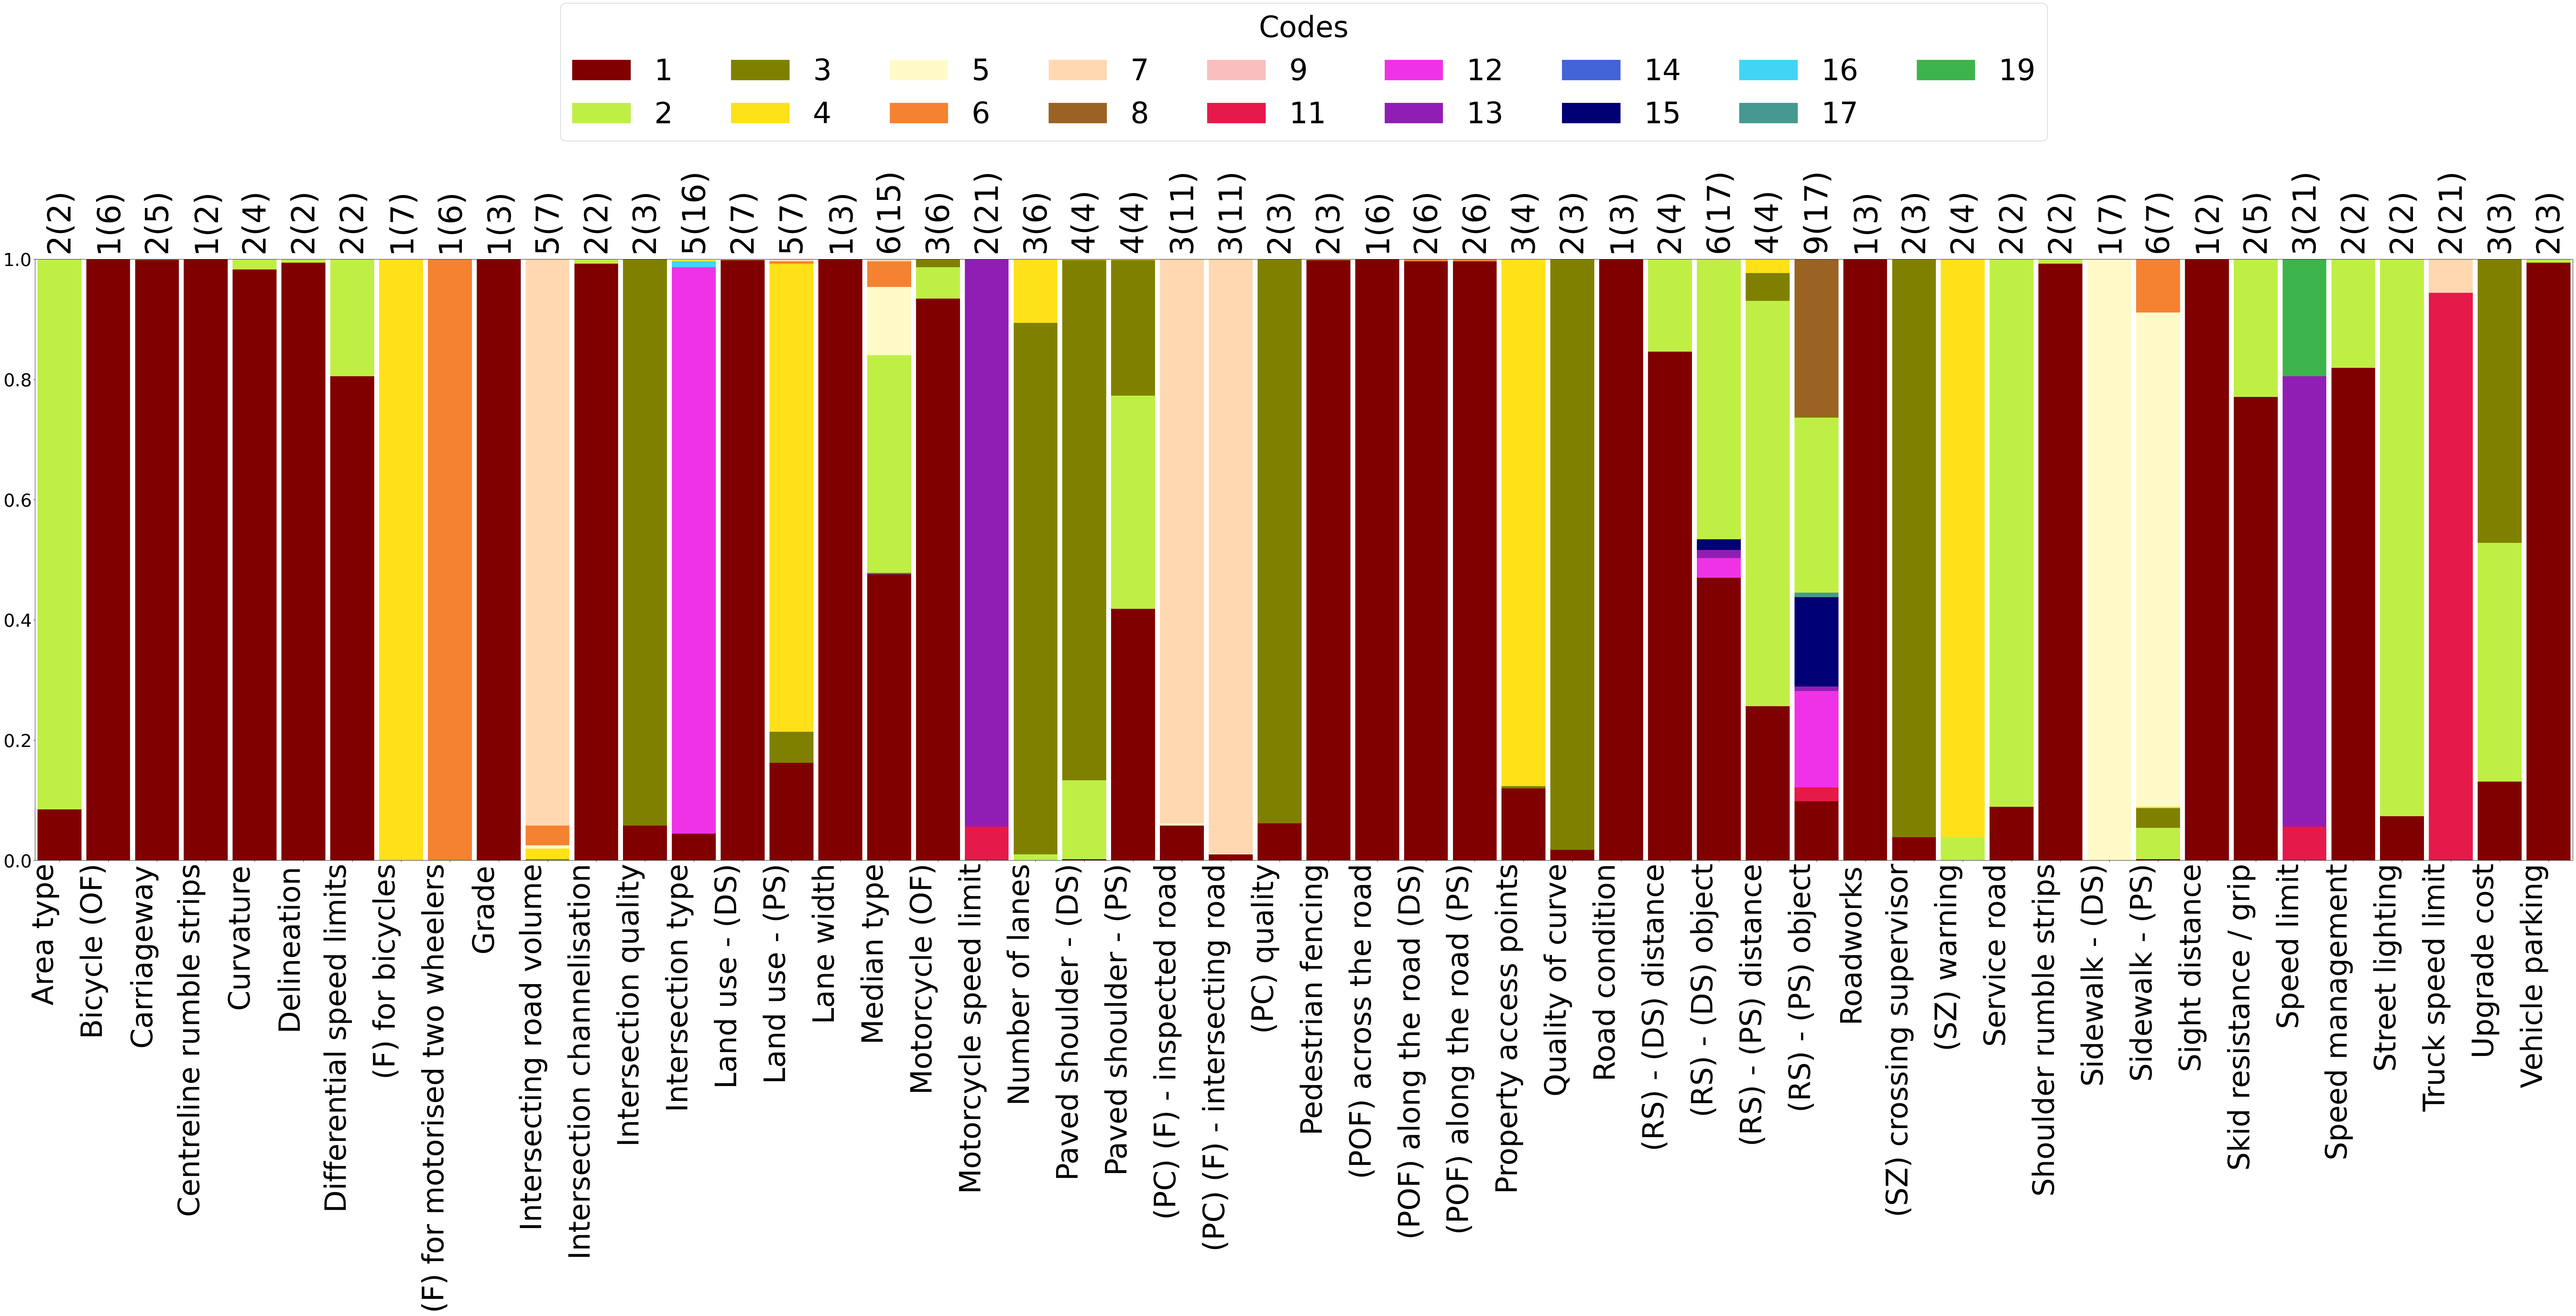

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
file_path = '/Users/stupong/Library/CloudStorage/OneDrive-UniversityCollegeLondon/General - V-RoAst2/Validation_distribution_new.csv'
data = pd.read_csv(file_path)

# Extract the last row to use as labels
last_row_text = data.iloc[-1].values

# Remove the last row from the data to avoid including it in the plot
data = data.iloc[:-1]

# Calculate the percentage of each class within each column
percentages = data.apply(lambda x: x.value_counts(normalize=True)).fillna(0)

# Create a color map
custom_colors = [
    '#800000', '#e6194b', '#f032e6', '#911eb4', '#4363d8', 
    '#000075', '#42d4f4', '#469990', '#3cb44b', '#bfef45', 
    '#808000', '#ffe119', '#fffac8', '#f58231', '#ffd8b1', 
    '#9a6324', '#fabebe', '#e6beff', '#aaffc3', '#a9a9a9'
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(80, 50))  # Decrease figure width for compactness

# Set the bar width and positions
bar_width = 0.9  # Increase bar width to reduce gaps
positions = np.arange(len(percentages.columns))

bottom = np.zeros(len(percentages.columns))

for i, value in enumerate(percentages.index):
    ax.bar(positions, percentages.loc[value], width=bar_width, label=value, bottom=bottom, color=custom_colors[i])
    bottom += percentages.loc[value]

# Function to add text labels on the top of each bar
def addlabels(x, labels):
    for i in range(len(x)):
        ax.text(i, 1.01, labels[i], ha='center', va='bottom', fontsize=70, rotation=90)  # Adjust font size

# Call the function to add text labels using the last row of the original data
addlabels(positions, last_row_text)

# Adjust x-axis labels
ax.set_xticks(positions)
ax.set_xticklabels(percentages.columns, fontsize=65, rotation=90, ha='right')  # Slightly reduce font size
ax.tick_params(axis='y', labelsize=40)

# Customize the legend
handles, labels = ax.get_legend_handles_labels()
sorted_labels = sorted(zip(handles, labels), key=lambda x: int(x[1]))
handles, labels = zip(*sorted_labels)
legend = ax.legend(
    handles, 
    labels, 
    title='Codes', 
    # bbox_to_anchor=(0.5, -0.2),  # Adjust legend position
    bbox_to_anchor=(0.5, 1.45),  # Adjust legend position
    loc='upper center', 
    fontsize=65, 
    title_fontsize=65, 
    ncol=9  # Adjust number of columns for compactness
)
legend.get_frame().set_linewidth(1.5)

# Adjust x-axis limits to fully display all bars
ax.set_xlim(-0.5, len(percentages.columns) - 0.5)

# Add more padding to avoid overlapping
plt.tight_layout(pad=2.0)
plt.show()
